In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import average_precision_score

df = pd.read_parquet("../data/processed/paysim_features.parquet")

if "week_bucket" not in df.columns:
    df["week_bucket"] = (df["step"] - df["step"].min()) // (24 * 7)
if "day_bucket" not in df.columns:
    df["day_bucket"] = (df["step"] - df["step"].min()) // 24

feature_columns = [
    "amount",
    "destination_transactions_last_24h",
    "destination_transactions_last_7d",
    "destination_avg_previous_amount",
    "destination_amount_deviation",
    "destination_is_first_transaction",
    "origin_balance_error",
    "destination_balance_error",
    "destination_balance_is_zero",
    "total_transactions",
    "total_transaction_amount",
    "avg_transaction_amount",
] + [c for c in df.columns if c.startswith("type_")]

dense_window = df[(df["day_bucket"] >= 5) & (df["day_bucket"] <= 16)]

def get_dense_period(days):
    subset = dense_window[dense_window["day_bucket"].isin(days)]
    return subset[feature_columns], subset["isFraud"]

def bootstrap_pr_auc_fast(model, X, y, n_bootstrap=200, seed=42):
    y_reset = y.reset_index(drop=True).values
    preds = model.predict_proba(X)[:, 1]
    rng = np.random.RandomState(seed)
    n = len(y_reset)
    scores = []
    for _ in range(n_bootstrap):
        idx = rng.randint(0, n, n)
        y_sample = y_reset[idx]
        if y_sample.sum() == 0:
            continue
        pred_sample = preds[idx]
        scores.append(average_precision_score(y_sample, pred_sample))
    return np.array(scores)

print(f"Loaded {len(df):,} rows, {len(dense_window):,} dense-window rows.")

Loaded 6,362,620 rows, 4,918,825 dense-window rows.


In [3]:
X_naive, y_naive = get_dense_period([5, 6, 7, 8, 9, 10, 11, 12, 13])
X_delay, y_delay = get_dense_period([5, 6, 7, 8, 9, 10, 11])
X_test_delay, y_test_delay = get_dense_period([14, 15, 16])

print(f"Naive train:       {len(X_naive):,} rows, {y_naive.sum():,} fraud")
print(f"Delay-aware train: {len(X_delay):,} rows, {y_delay.sum():,} fraud")
print(f"Shared test:       {len(X_test_delay):,} rows, {y_test_delay.sum():,} fraud")

Naive train:       3,716,183 rows, 2,363 fraud
Delay-aware train: 2,889,724 rows, 1,875 fraud
Shared test:       1,202,642 rows, 822 fraud


In [4]:
lgb_naive = lgb.LGBMClassifier(
    n_estimators=200, num_leaves=15, max_depth=5,
    min_child_samples=100, reg_alpha=1.0, reg_lambda=1.0,
    scale_pos_weight=20, random_state=42, verbose=-1
)
lgb_naive.fit(X_naive, y_naive)

lgb_delay_aware = lgb.LGBMClassifier(
    n_estimators=200, num_leaves=15, max_depth=5,
    min_child_samples=100, reg_alpha=1.0, reg_lambda=1.0,
    scale_pos_weight=20, random_state=42, verbose=-1
)
lgb_delay_aware.fit(X_delay, y_delay)

print("Both models trained.")

Both models trained.


In [5]:
pr_auc_naive = average_precision_score(y_test_delay, lgb_naive.predict_proba(X_test_delay)[:, 1])
pr_auc_delay_aware = average_precision_score(y_test_delay, lgb_delay_aware.predict_proba(X_test_delay)[:, 1])

print(f"Naive model PR-AUC:       {pr_auc_naive:.4f}")
print(f"Delay-aware model PR-AUC: {pr_auc_delay_aware:.4f}")
print(f"Difference:               {pr_auc_delay_aware - pr_auc_naive:+.4f}")

Naive model PR-AUC:       0.8352
Delay-aware model PR-AUC: 0.7567
Difference:               -0.0785


In [6]:
X_naive, y_naive = get_dense_period([7, 8, 9, 10, 11, 12, 13])   # 7 days, ends at boundary
X_delay, y_delay = get_dense_period([5, 6, 7, 8, 9, 10, 11])      # 7 days, shifted back 2

In [7]:
# Re-defined with matched 7-day windows
X_naive, y_naive = get_dense_period([7, 8, 9, 10, 11, 12, 13])
X_delay, y_delay = get_dense_period([5, 6, 7, 8, 9, 10, 11])
X_test_delay, y_test_delay = get_dense_period([14, 15, 16])

print(f"Naive train:       {len(X_naive):,} rows, {y_naive.sum():,} fraud")
print(f"Delay-aware train: {len(X_delay):,} rows, {y_delay.sum():,} fraud")
print(f"Shared test:       {len(X_test_delay):,} rows, {y_test_delay.sum():,} fraud")

Naive train:       2,854,595 rows, 1,863 fraud
Delay-aware train: 2,889,724 rows, 1,875 fraud
Shared test:       1,202,642 rows, 822 fraud


In [8]:
lgb_naive = lgb.LGBMClassifier(
    n_estimators=200, num_leaves=15, max_depth=5,
    min_child_samples=100, reg_alpha=1.0, reg_lambda=1.0,
    scale_pos_weight=20, random_state=42, verbose=-1
)
lgb_naive.fit(X_naive, y_naive)

lgb_delay_aware = lgb.LGBMClassifier(
    n_estimators=200, num_leaves=15, max_depth=5,
    min_child_samples=100, reg_alpha=1.0, reg_lambda=1.0,
    scale_pos_weight=20, random_state=42, verbose=-1
)
lgb_delay_aware.fit(X_delay, y_delay)

pr_auc_naive_matched = average_precision_score(y_test_delay, lgb_naive.predict_proba(X_test_delay)[:, 1])
pr_auc_delay_matched = average_precision_score(y_test_delay, lgb_delay_aware.predict_proba(X_test_delay)[:, 1])

print(f"Naive (matched, days 7-13) PR-AUC:   {pr_auc_naive_matched:.4f}")
print(f"Delay-aware (days 5-11) PR-AUC:      {pr_auc_delay_matched:.4f}")
print(f"Difference:                          {pr_auc_delay_matched - pr_auc_naive_matched:+.4f}")

Naive (matched, days 7-13) PR-AUC:   0.7819
Delay-aware (days 5-11) PR-AUC:      0.7567
Difference:                          -0.0253


In [9]:
# Bootstrap CI — same discipline as Phase B
scores_naive_m = bootstrap_pr_auc_fast(lgb_naive, X_test_delay, y_test_delay)
scores_delay_m = bootstrap_pr_auc_fast(lgb_delay_aware, X_test_delay, y_test_delay)

lo_nm, hi_nm = np.percentile(scores_naive_m, [2.5, 97.5])
lo_dm, hi_dm = np.percentile(scores_delay_m, [2.5, 97.5])

print(f"Naive (matched):       PR-AUC = {pr_auc_naive_matched:.4f}, 95% CI = [{lo_nm:.4f}, {hi_nm:.4f}]")
print(f"Delay-aware (matched): PR-AUC = {pr_auc_delay_matched:.4f}, 95% CI = [{lo_dm:.4f}, {hi_dm:.4f}]")

Naive (matched):       PR-AUC = 0.7819, 95% CI = [0.7488, 0.8084]
Delay-aware (matched): PR-AUC = 0.7567, 95% CI = [0.7244, 0.7886]


In [10]:
# Delay sweep — fixed 7-day training window, shifted back by d days
# Capped at d=2 so train_start never drops below day 5 (dense-window floor)
delay_days = [0, 1, 2]
results = []

for d in delay_days:
    train_end = 13 - d
    train_start = train_end - 6  # 7-day window
    train_period = list(range(train_start, train_end + 1))
    
    X_d, y_d = get_dense_period(train_period)
    
    model = lgb.LGBMClassifier(
        n_estimators=200, num_leaves=15, max_depth=5,
        min_child_samples=100, reg_alpha=1.0, reg_lambda=1.0,
        scale_pos_weight=20, random_state=42, verbose=-1
    )
    model.fit(X_d, y_d)
    
    pr_auc = average_precision_score(y_test_delay, model.predict_proba(X_test_delay)[:, 1])
    scores_boot = bootstrap_pr_auc_fast(model, X_test_delay, y_test_delay)
    lo, hi = np.percentile(scores_boot, [2.5, 97.5])
    
    results.append({
        'delay_days': d,
        'train_period': train_period,
        'pr_auc': pr_auc,
        'ci_lower': lo,
        'ci_upper': hi
    })
    print(f"Delay={d}d, train={train_period}: PR-AUC={pr_auc:.4f}, CI=[{lo:.4f}, {hi:.4f}]")

results_df = pd.DataFrame(results)
results_df

Delay=0d, train=[7, 8, 9, 10, 11, 12, 13]: PR-AUC=0.7819, CI=[0.7488, 0.8084]
Delay=1d, train=[6, 7, 8, 9, 10, 11, 12]: PR-AUC=0.7743, CI=[0.7444, 0.8000]
Delay=2d, train=[5, 6, 7, 8, 9, 10, 11]: PR-AUC=0.7567, CI=[0.7244, 0.7886]


,delay_days,train_period,pr_auc,ci_lower,ci_upper
0,0,"[7, 8, 9, 10, 11, 12, 13]",0.781930,0.748780,0.80838
1,1,"[6, 7, 8, 9, 10, 11, 12]",0.774305,0.744423,0.80002
2,2,"[5, 6, 7, 8, 9, 10, 11]",0.756677,0.724432,0.78859


In [12]:
# Get transaction amounts for the test set (needed for FN cost)
# Adjust column name if your feature-engineered X_test_delay dropped 'amount'
amounts_test = df.loc[X_test_delay.index, 'amount']  # confirm this alignment is correct

REVIEW_COST = 1
BLOCK_FP_COST = 5

# Use your best model's predicted probabilities (pick lgb_delay_aware, since
# that's the realistic deployment scenario — you won't have future labels)
probs = lgb_delay_aware.predict_proba(X_test_delay)[:, 1]

def evaluate_thresholds(y_true, probs, amounts, t_review, t_block):
    """
    t_review < t_block. Below t_review -> ALLOW, between -> REVIEW, above -> BLOCK.
    """
    tier = np.where(probs >= t_block, 'BLOCK',
            np.where(probs >= t_review, 'REVIEW', 'ALLOW'))
    
    y_true = np.array(y_true)
    total_cost = 0
    
    # Missed fraud: actual fraud that was ALLOWed
    missed_fraud_mask = (tier == 'ALLOW') & (y_true == 1)
    total_cost += amounts[missed_fraud_mask].sum()
    
    # False block: legit transaction BLOCKed
    fp_block_mask = (tier == 'BLOCK') & (y_true == 0)
    total_cost += fp_block_mask.sum() * BLOCK_FP_COST
    
    # Review cost: legit transaction sent to REVIEW (fraud sent to REVIEW is a "catch", not a cost)
    review_mask = (tier == 'REVIEW') & (y_true == 0)
    total_cost += review_mask.sum() * REVIEW_COST
    
    return {
        'total_cost': total_cost,
        'n_blocked': (tier == 'BLOCK').sum(),
        'n_reviewed': (tier == 'REVIEW').sum(),
        'n_allowed': (tier == 'ALLOW').sum(),
        'fraud_caught_block': ((tier == 'BLOCK') & (y_true == 1)).sum(),
        'fraud_caught_review': ((tier == 'REVIEW') & (y_true == 1)).sum(),
        'fraud_missed': missed_fraud_mask.sum(),
    }

# Grid search over threshold pairs
results_cost = []
for t_review in np.arange(0.05, 0.6, 0.05):
    for t_block in np.arange(t_review + 0.05, 1.0, 0.05):
        r = evaluate_thresholds(y_test_delay, probs, amounts_test, t_review, t_block)
        r['t_review'] = t_review
        r['t_block'] = t_block
        results_cost.append(r)

cost_df = pd.DataFrame(results_cost).sort_values('total_cost')
cost_df.head(10)

,total_cost,n_blocked,n_reviewed,n_allowed,fraud_caught_block,fraud_caught_review,fraud_missed,t_review,t_block
17,48631270.57,902,11956,1189784,667,98,57,0.05,0.95
16,48631334.57,919,11939,1189784,668,97,57,0.05,0.90
15,48631382.57,933,11925,1189784,670,95,57,0.05,0.85
14,48631518.57,970,11888,1189784,673,92,57,0.05,0.80
13,48631550.57,978,11880,1189784,673,92,57,0.05,0.75
12,48631666.57,1008,11850,1189784,674,91,57,0.05,0.70
11,48631806.57,1043,11815,1189784,674,91,57,0.05,0.65
10,48631978.57,1088,11770,1189784,676,89,57,0.05,0.60
9,48632042.57,1105,11753,1189784,677,88,57,0.05,0.55
8,48632134.57,1132,11726,1189784,681,84,57,0.05,0.50


In [13]:
# Widen the review threshold search downward, and check if amounts dwarf the fixed costs
print(f"Mean fraud amount: {df.loc[X_test_delay.index, 'amount'][y_test_delay==1].mean():.2f}")
print(f"Mean legit amount:  {df.loc[X_test_delay.index, 'amount'][y_test_delay==0].mean():.2f}")

results_cost = []
for t_review in np.arange(0.005, 0.6, 0.025):
    for t_block in np.arange(t_review + 0.02, 1.0, 0.05):
        r = evaluate_thresholds(y_test_delay, probs, amounts_test, t_review, t_block)
        r['t_review'] = t_review
        r['t_block'] = t_block
        results_cost.append(r)

cost_df = pd.DataFrame(results_cost).sort_values('total_cost')
cost_df.head(10)

Mean fraud amount: 1657564.96
Mean legit amount:  181600.01


,total_cost,n_blocked,n_reviewed,n_allowed,fraud_caught_block,fraud_caught_review,fraud_missed,t_review,t_block
19,47431503.89,893,28439,1173310,663,130,29,0.005,0.975
18,47431551.89,910,28422,1173310,668,125,29,0.005,0.925
17,47431615.89,927,28405,1173310,669,124,29,0.005,0.875
16,47431723.89,957,28375,1173310,672,121,29,0.005,0.825
15,47431795.89,976,28356,1173310,673,120,29,0.005,0.775
14,47431839.89,987,28345,1173310,673,120,29,0.005,0.725
13,47431967.89,1020,28312,1173310,674,119,29,0.005,0.675
12,47432111.89,1057,28275,1173310,675,118,29,0.005,0.625
11,47432275.89,1100,28232,1173310,677,116,29,0.005,0.575
10,47432319.89,1111,28221,1173310,677,116,29,0.005,0.525


In [14]:
results_cost = []
for t_review in [0.0001, 0.0005, 0.001, 0.002, 0.003, 0.005, 0.01, 0.02, 0.05, 0.1]:
    for t_block in [0.5, 0.7, 0.9]:  # block barely matters, don't waste grid density here
        r = evaluate_thresholds(y_test_delay, probs, amounts_test, t_review, t_block)
        r['t_review'] = t_review
        r['t_block'] = t_block
        results_cost.append(r)

cost_df2 = pd.DataFrame(results_cost).sort_values('total_cost')
cost_df2.head(15)

,total_cost,n_blocked,n_reviewed,n_allowed,fraud_caught_block,fraud_caught_review,fraud_missed,t_review,t_block
2,45378363.29,919,75851,1125872,668,132,22,0.0001,0.9
1,45378695.29,1008,75762,1125872,674,126,22,0.0001,0.7
0,45379163.29,1132,75638,1125872,681,119,22,0.0001,0.5
5,45774141.05,919,34870,1166853,668,131,23,0.0005,0.9
4,45774473.05,1008,34781,1166853,674,125,23,0.0005,0.7
3,45774941.05,1132,34657,1166853,681,118,23,0.0005,0.5
8,46866866.54,919,31123,1170600,668,127,27,0.0010,0.9
7,46867198.54,1008,31034,1170600,674,121,27,0.0010,0.7
6,46867666.54,1132,30910,1170600,681,114,27,0.0010,0.5
20,47431241.89,919,28067,1173656,668,125,29,0.0100,0.9


In [15]:
results_cost = []
for t_review in [0.000001, 0.00001, 0.00003, 0.00005, 0.0001, 0.0003, 0.0005]:
    for t_block in [0.7, 0.9]:
        r = evaluate_thresholds(y_test_delay, probs, amounts_test, t_review, t_block)
        r['t_review'] = t_review
        r['t_block'] = t_block
        results_cost.append(r)

cost_df3 = pd.DataFrame(results_cost).sort_values('total_cost')
cost_df3[['t_review', 't_block', 'total_cost', 'n_reviewed', 'n_allowed', 'fraud_missed']]

,t_review,t_block,total_cost,n_reviewed,n_allowed,fraud_missed
11,0.000300,0.9,45348186.29,45674,1156049,22
10,0.000300,0.7,45348518.29,45585,1156049,22
9,0.000100,0.9,45378363.29,75851,1125872,22
8,0.000100,0.7,45378695.29,75762,1125872,22
7,0.000050,0.9,45413768.29,111256,1090467,22
6,0.000050,0.7,45414100.29,111167,1090467,22
5,0.000030,0.9,45515550.29,213038,988685,22
4,0.000030,0.7,45515882.29,212949,988685,22
3,0.000010,0.9,45690152.29,387640,814083,22
2,0.000010,0.7,45690484.29,387551,814083,22


In [16]:
results_cost = []
for t_review in [0.00015, 0.0002, 0.00025, 0.0003, 0.00035, 0.0004, 0.00045]:
    for t_block in [0.7, 0.9]:
        r = evaluate_thresholds(y_test_delay, probs, amounts_test, t_review, t_block)
        r['t_review'] = t_review
        r['t_block'] = t_block
        results_cost.append(r)

cost_df4 = pd.DataFrame(results_cost).sort_values('total_cost')
cost_df4[['t_review', 't_block', 'total_cost', 'n_reviewed', 'n_allowed', 'fraud_caught_block', 'fraud_caught_review', 'fraud_missed']]

,t_review,t_block,total_cost,n_reviewed,n_allowed,fraud_caught_block,fraud_caught_review,fraud_missed
11,0.00040,0.9,45340635.29,38123,1163600,668,132,22
10,0.00040,0.7,45340967.29,38034,1163600,674,126,22
9,0.00035,0.9,45344468.29,41956,1159767,668,132,22
8,0.00035,0.7,45344800.29,41867,1159767,674,126,22
7,0.00030,0.9,45348186.29,45674,1156049,668,132,22
6,0.00030,0.7,45348518.29,45585,1156049,674,126,22
5,0.00025,0.9,45350464.29,47952,1153771,668,132,22
4,0.00025,0.7,45350796.29,47863,1153771,674,126,22
3,0.00020,0.9,45356685.29,54173,1147550,668,132,22
2,0.00020,0.7,45357017.29,54084,1147550,674,126,22


In [17]:
for t_block in [0.9, 0.93, 0.95, 0.97, 0.99]:
    r = evaluate_thresholds(y_test_delay, probs, amounts_test, 0.0004, t_block)
    print(f"t_block={t_block}: cost={r['total_cost']:.2f}, n_blocked={r['n_blocked']}, fraud_caught_block={r['fraud_caught_block']}")

t_block=0.9: cost=45340635.29, n_blocked=919, fraud_caught_block=668
t_block=0.93: cost=45340583.29, n_blocked=905, fraud_caught_block=667
t_block=0.95: cost=45340571.29, n_blocked=902, fraud_caught_block=667
t_block=0.97: cost=45340563.29, n_blocked=897, fraud_caught_block=664
t_block=0.99: cost=45340339.29, n_blocked=835, fraud_caught_block=658


c:\Users\Anushka\OneDrive\Desktop\fraud-detection-project\fraud_env\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\Anushka\AppData\Local\Temp\ipykernel_20904\3555174641.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_fraud, X_shap_sample, show=True)


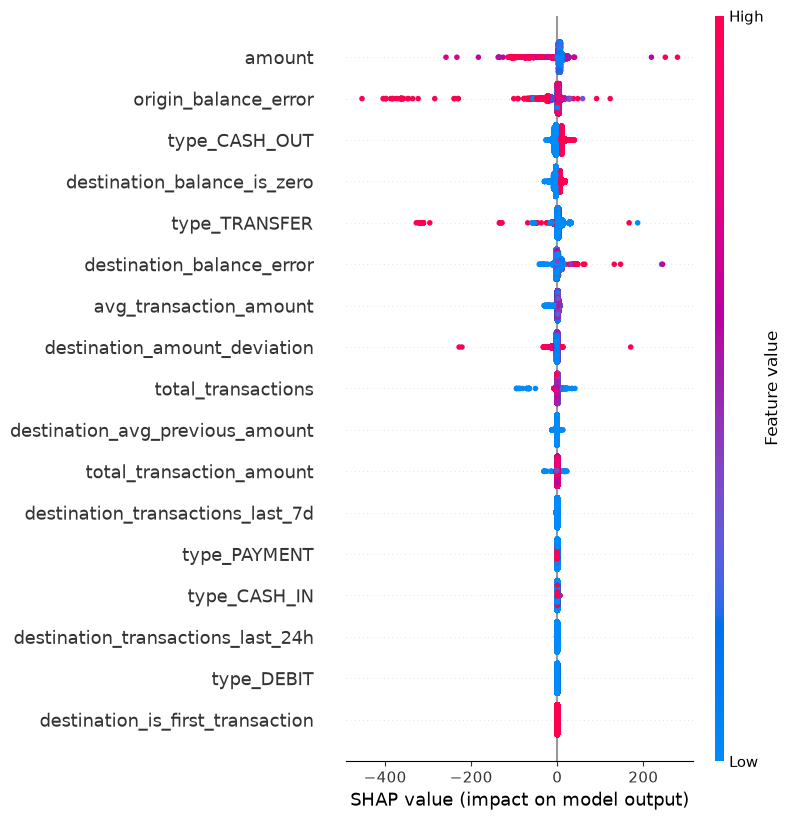

In [18]:
import shap

# TreeExplainer is fast and exact for LightGBM — don't use KernelExplainer, unnecessary here
explainer = shap.TreeExplainer(lgb_delay_aware)

# Don't run SHAP on the full ~1.2M-row test set — it's unnecessary and slow.
# A random sample is enough for stable global importance; stratify to keep fraud cases represented
sample_size = 20000
np.random.seed(42)
sample_idx = np.random.choice(X_test_delay.index, size=sample_size, replace=False)
X_shap_sample = X_test_delay.loc[sample_idx]

shap_values = explainer.shap_values(X_shap_sample)

# For binary classification, LightGBM's TreeExplainer may return a list [class0, class1]
# or a single array depending on version — check before plotting
if isinstance(shap_values, list):
    shap_values_fraud = shap_values[1]  # class 1 = fraud
else:
    shap_values_fraud = shap_values

shap.summary_plot(shap_values_fraud, X_shap_sample, show=True)

c:\Users\Anushka\OneDrive\Desktop\fraud-detection-project\fraud_env\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\Anushka\AppData\Local\Temp\ipykernel_20904\1458108022.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_fraud_only, X_shap_fraud, show=True)


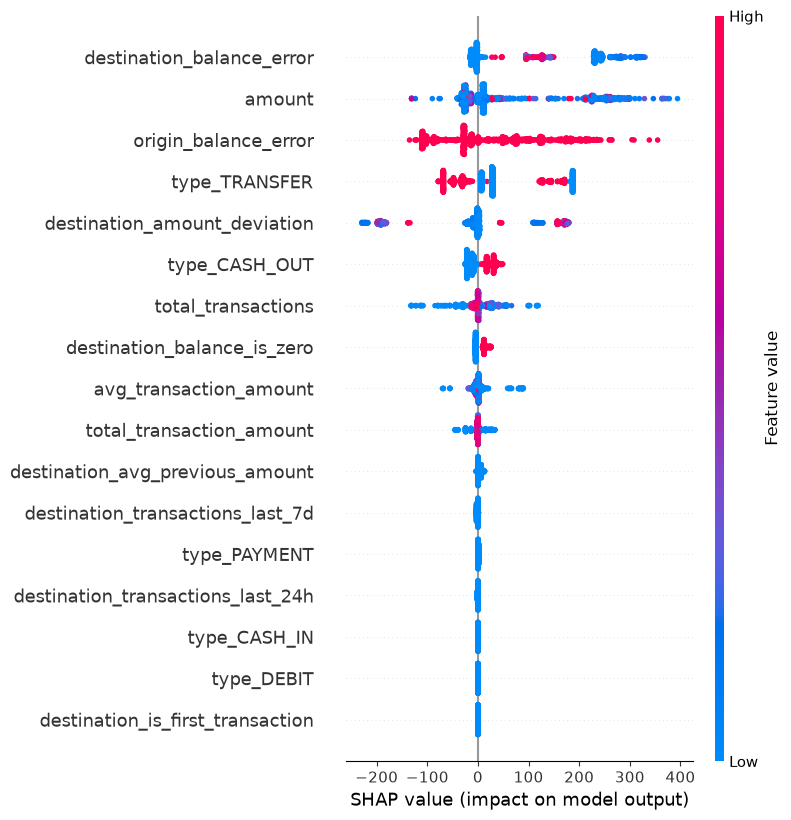

In [19]:
# Get all fraud rows specifically, not a random sample
fraud_idx = y_test_delay[y_test_delay == 1].index
X_shap_fraud = X_test_delay.loc[fraud_idx]

shap_values_fraud_only = explainer.shap_values(X_shap_fraud)
if isinstance(shap_values_fraud_only, list):
    shap_values_fraud_only = shap_values_fraud_only[1]

shap.summary_plot(shap_values_fraud_only, X_shap_fraud, show=True)

In [20]:
# Check correlation between balance-error features and type, within fraud cases only
corr_check = X_shap_fraud[['origin_balance_error', 'destination_balance_error', 
                             'type_TRANSFER', 'type_CASH_OUT']].corr()
print(corr_check)

                           origin_balance_error  destination_balance_error  \
origin_balance_error                   1.000000                  -0.069689   
destination_balance_error             -0.069689                   1.000000   
type_TRANSFER                         -0.034900                   0.409845   
type_CASH_OUT                          0.034900                  -0.409845   

                           type_TRANSFER  type_CASH_OUT  
origin_balance_error           -0.034900       0.034900  
destination_balance_error       0.409845      -0.409845  
type_TRANSFER                   1.000000      -1.000000  
type_CASH_OUT                  -1.000000       1.000000  


In [21]:
# Does removing type features hurt performance much, given balance-error features exist?
type_cols = ['type_CASH_OUT', 'type_TRANSFER', 'type_PAYMENT', 'type_CASH_IN', 'type_DEBIT']
X_no_type = X_delay.drop(columns=[c for c in type_cols if c in X_delay.columns])
X_test_no_type = X_test_delay.drop(columns=[c for c in type_cols if c in X_test_delay.columns])

model_no_type = lgb.LGBMClassifier(
    n_estimators=200, num_leaves=15, max_depth=5,
    min_child_samples=100, reg_alpha=1.0, reg_lambda=1.0,
    scale_pos_weight=20, random_state=42, verbose=-1
)
model_no_type.fit(X_no_type, y_delay)
pr_auc_no_type = average_precision_score(y_test_delay, model_no_type.predict_proba(X_test_no_type)[:, 1])
print(f"With type: {pr_auc_delay_matched:.4f}")
print(f"Without type: {pr_auc_no_type:.4f}")

With type: 0.7567
Without type: 0.7564


In [23]:
for col in X_delay.columns:
    print(col)

amount
destination_transactions_last_24h
destination_transactions_last_7d
destination_avg_previous_amount
destination_amount_deviation
destination_is_first_transaction
origin_balance_error
destination_balance_error
destination_balance_is_zero
total_transactions
total_transaction_amount
avg_transaction_amount
type_CASH_IN
type_CASH_OUT
type_DEBIT
type_PAYMENT
type_TRANSFER


In [24]:
step_cols = ['total_transactions', 'total_transaction_amount', 'avg_transaction_amount']
X_no_step = X_delay.drop(columns=step_cols)
X_test_no_step = X_test_delay.drop(columns=step_cols)

model_no_step = lgb.LGBMClassifier(
    n_estimators=200, num_leaves=15, max_depth=5,
    min_child_samples=100, reg_alpha=1.0, reg_lambda=1.0,
    scale_pos_weight=20, random_state=42, verbose=-1
)
model_no_step.fit(X_no_step, y_delay)
pr_auc_no_step = average_precision_score(y_test_delay, model_no_step.predict_proba(X_test_no_step)[:, 1])
print(f"With step-level features: {pr_auc_delay_matched:.4f}")
print(f"Without step-level features: {pr_auc_no_step:.4f}")

With step-level features: 0.7567
Without step-level features: 0.6219


In [25]:
# Leakage-safe version: only count transactions that occurred BEFORE this one,
# within the same hour — not the full-hour total (which includes future rows)
df_sorted = df.sort_values(['step', 'timestamp'])  # adjust to your actual within-step ordering column
df_sorted['running_count_this_step'] = df_sorted.groupby('step').cumcount()

# Compare: does the leaky full-hour total correlate suspiciously well with
# just "how far into the day/window this row falls" rather than real fraud signal?
print(df[['total_transactions', 'day_bucket']].groupby('day_bucket')['total_transactions'].agg(['mean', 'std', 'nunique']))

                    mean           std  nunique
day_bucket                                     
0           38365.353599  10884.093561       24
1           32864.144338   9187.736410       22
2             550.067290    338.206367       10
3            7602.156091   2305.461706       13
4            4423.761467   1719.822173       11
5           32137.015097   8543.426825       24
6           30919.730101   9481.514338       24
7           33079.200268  10057.545611       21
8           30188.065982   7730.168941       23
9           29148.001041  10090.669209       21
10          30173.158575   8247.857994       22
11          25794.108481   7710.538529       22
12          31638.176972   9818.528639       24
13          28741.331440   8074.378079       23
14          29830.774189   9157.929536       22
15          28048.494853   9366.155824       21
16          30698.351888   9343.809371       22
17           2776.143388   1487.526641       18
18           2221.913274   1274.446313  

In [26]:
# Causal, leakage-free version: cumulative count/sum/mean of transactions
# that occurred strictly BEFORE this one, within the same step (hour) only.
# Requires a genuine within-step ordering column — if you don't have exact
# timestamps finer than 'step' (PaySim's step is hour-granularity only),
# you cannot truly order transactions within an hour, and this feature
# may be unfixable at hour granularity — worth confirming your data has
# sub-hour ordering before trusting this fix.

df_sorted = df.sort_values(['step']).reset_index(drop=True)

# If you have NO finer-than-step ordering, the honest move is to compute
# a TRAILING window ending at the previous step, not the current one —
# i.e., "how much volume happened in prior hours" rather than "this hour"
step_stats_trailing = (
    df.groupby("step")["amount"]
      .agg(total_transactions="count", total_transaction_amount="sum", avg_transaction_amount="mean")
      .reset_index()
      .sort_values("step")
)
step_stats_trailing[["total_transactions", "total_transaction_amount", "avg_transaction_amount"]] = \
    step_stats_trailing[["total_transactions", "total_transaction_amount", "avg_transaction_amount"]].shift(1)

df_fixed = df.drop(columns=["total_transactions", "total_transaction_amount", "avg_transaction_amount"], errors='ignore')
df_fixed = df_fixed.merge(step_stats_trailing, on="step", how="left")
df_fixed[["total_transactions", "total_transaction_amount", "avg_transaction_amount"]] = \
    df_fixed[["total_transactions", "total_transaction_amount", "avg_transaction_amount"]].fillna(0)

print("Leakage-free (previous-hour) version created.")

Leakage-free (previous-hour) version created.


In [27]:
dense_window_fixed = df_fixed[(df_fixed["day_bucket"] >= 5) & (df_fixed["day_bucket"] <= 16)]

def get_dense_period_fixed(days):
    subset = dense_window_fixed[dense_window_fixed["day_bucket"].isin(days)]
    return subset[feature_columns], subset["isFraud"]

X_delay_fixed, y_delay_fixed = get_dense_period_fixed([5, 6, 7, 8, 9, 10, 11])
X_test_fixed, y_test_fixed = get_dense_period_fixed([14, 15, 16])

model_fixed = lgb.LGBMClassifier(
    n_estimators=200, num_leaves=15, max_depth=5,
    min_child_samples=100, reg_alpha=1.0, reg_lambda=1.0,
    scale_pos_weight=20, random_state=42, verbose=-1
)
model_fixed.fit(X_delay_fixed, y_delay_fixed)
pr_auc_fixed = average_precision_score(y_test_fixed, model_fixed.predict_proba(X_test_fixed)[:, 1])
print(f"Original (leaky, current-hour totals): {pr_auc_delay_matched:.4f}")
print(f"Fixed (previous-hour totals only):     {pr_auc_fixed:.4f}")

Original (leaky, current-hour totals): 0.7567
Fixed (previous-hour totals only):     0.4491


In [28]:
# Spot check: for a few steps, does trailing value match the PREVIOUS step's actual total?
check = df.groupby('step')['amount'].count().reset_index(name='actual_count')
check_merged = df_fixed[['step', 'total_transactions']].drop_duplicates().merge(check, on='step')
check_merged['expected_trailing'] = check['actual_count'].shift(1).values[:len(check_merged)]
print(check_merged.head(20))

    step  total_transactions  actual_count  expected_trailing
0      1                 0.0          2708                NaN
1      2              2708.0          1014             2708.0
2      3              1014.0           552             1014.0
3      4               552.0           565              552.0
4      5               565.0           665              565.0
5      6               665.0          1660              665.0
6      7              1660.0          6837             1660.0
7      8              6837.0         21097             6837.0
8      9             21097.0         37628            21097.0
9     10             37628.0         35991            37628.0
10    11             35991.0         37241            35991.0
11    12             37241.0         36153            37241.0
12    13             36153.0         37515            36153.0
13    14             37515.0         41485            37515.0
14    15             41485.0         44609            41485.0
15    16

In [29]:
# Does the trailing version add anything over having no step-level features at all?
print(f"No step features at all:        {pr_auc_no_step:.4f}")  # from your earlier cell: 0.6219
print(f"Leakage-free trailing version:  {pr_auc_fixed:.4f}")     # 0.4491

No step features at all:        0.6219
Leakage-free trailing version:  0.4491


In [30]:
feature_columns = [
    "amount",
    "destination_transactions_last_24h",
    "destination_transactions_last_7d",
    "destination_avg_previous_amount",
    "destination_amount_deviation",
    "destination_is_first_transaction",
    "origin_balance_error",
    "destination_balance_error",
    "destination_balance_is_zero",
] + [c for c in df.columns if c.startswith("type_")]

# Redefine get_dense_period with the corrected feature list
def get_dense_period(days):
    subset = dense_window[dense_window["day_bucket"].isin(days)]
    return subset[feature_columns], subset["isFraud"]

In [31]:
# Corrected feature list — drop the 3 leaky step-level features permanently
feature_columns = [
    "amount",
    "destination_transactions_last_24h",
    "destination_transactions_last_7d",
    "destination_avg_previous_amount",
    "destination_amount_deviation",
    "destination_is_first_transaction",
    "origin_balance_error",
    "destination_balance_error",
    "destination_balance_is_zero",
] + [c for c in df.columns if c.startswith("type_")]

def get_dense_period(days):
    subset = dense_window[dense_window["day_bucket"].isin(days)]
    return subset[feature_columns], subset["isFraud"]

# Rebuild your original baseline split with corrected features
X_train_initial, y_train_initial = get_dense_period([5, 6, 7])
X_eval1, y_eval1 = get_dense_period([8, 9, 10])

lgb_baseline_fixed = lgb.LGBMClassifier(
    n_estimators=200, num_leaves=15, max_depth=5,
    min_child_samples=100, reg_alpha=1.0, reg_lambda=1.0,
    scale_pos_weight=20, random_state=42, verbose=-1
)
lgb_baseline_fixed.fit(X_train_initial, y_train_initial)

pr_auc_baseline_fixed = average_precision_score(
    y_eval1, lgb_baseline_fixed.predict_proba(X_eval1)[:, 1]
)

print(f"Original (leaky) baseline PR-AUC on eval_1:  0.8327")
print(f"Corrected (leakage-free) baseline PR-AUC on eval_1: {pr_auc_baseline_fixed:.4f}")

Original (leaky) baseline PR-AUC on eval_1:  0.8327
Corrected (leakage-free) baseline PR-AUC on eval_1: 0.4999


In [32]:
X_eval2, y_eval2 = get_dense_period([11, 12, 13])
X_held_out, y_held_out = get_dense_period([14, 15, 16])

pr_auc_eval1_fixed = average_precision_score(y_eval1, lgb_baseline_fixed.predict_proba(X_eval1)[:, 1])
pr_auc_eval2_fixed = average_precision_score(y_eval2, lgb_baseline_fixed.predict_proba(X_eval2)[:, 1])
pr_auc_held_out_fixed = average_precision_score(y_held_out, lgb_baseline_fixed.predict_proba(X_held_out)[:, 1])

print(f"eval_1:    {pr_auc_eval1_fixed:.4f}")
print(f"eval_2:    {pr_auc_eval2_fixed:.4f}")
print(f"held_out:  {pr_auc_held_out_fixed:.4f}")

eval_1:    0.4999
eval_2:    0.5340
held_out:  0.6016


In [33]:
# Bootstrap CIs — same function you already have (bootstrap_pr_auc_fast)
scores_eval1_fixed = bootstrap_pr_auc_fast(lgb_baseline_fixed, X_eval1, y_eval1)
scores_eval2_fixed = bootstrap_pr_auc_fast(lgb_baseline_fixed, X_eval2, y_eval2)
scores_held_out_fixed = bootstrap_pr_auc_fast(lgb_baseline_fixed, X_held_out, y_held_out)

for name, scores, point in [
    ("eval_1", scores_eval1_fixed, pr_auc_eval1_fixed),
    ("eval_2", scores_eval2_fixed, pr_auc_eval2_fixed),
    ("held_out", scores_held_out_fixed, pr_auc_held_out_fixed),
]:
    lo, hi = np.percentile(scores, [2.5, 97.5])
    print(f"{name}: PR-AUC = {point:.4f}, 95% CI = [{lo:.4f}, {hi:.4f}]")

eval_1: PR-AUC = 0.4999, 95% CI = [0.4648, 0.5285]
eval_2: PR-AUC = 0.5340, 95% CI = [0.5011, 0.5678]
held_out: PR-AUC = 0.6016, 95% CI = [0.5624, 0.6363]


In [34]:
# Retraining test — same as before, but on corrected features
X_retrain_fixed, y_retrain_fixed = get_dense_period([5, 6, 7, 8, 9, 10])

lgb_retrained_fixed = lgb.LGBMClassifier(
    n_estimators=200, num_leaves=15, max_depth=5,
    min_child_samples=100, reg_alpha=1.0, reg_lambda=1.0,
    scale_pos_weight=20, random_state=42, verbose=-1
)
lgb_retrained_fixed.fit(X_retrain_fixed, y_retrain_fixed)

pr_auc_retrained_fixed = average_precision_score(
    y_held_out, lgb_retrained_fixed.predict_proba(X_held_out)[:, 1]
)

print(f"Original model (days 5-7) on held_out:    {pr_auc_held_out_fixed:.4f}")
print(f"Retrained model (days 5-10) on held_out:  {pr_auc_retrained_fixed:.4f}")
print(f"Difference: {pr_auc_retrained_fixed - pr_auc_held_out_fixed:+.4f}")

Original model (days 5-7) on held_out:    0.6016
Retrained model (days 5-10) on held_out:  0.3433
Difference: -0.2583


In [35]:
# Sanity checks — run all of these before interpreting anything above
print("Fraud counts per period:")
print(f"eval_1:    {y_eval1.sum()} / {len(y_eval1)}")
print(f"eval_2:    {y_eval2.sum()} / {len(y_eval2)}")
print(f"held_out:  {y_held_out.sum()} / {len(y_held_out)}")
print(f"retrain (5-10): {y_retrain_fixed.sum()} / {len(y_retrain_fixed)}")

# Confirm the retrained model actually trained on MORE fraud, not less
print(f"\nOriginal train (5-7) fraud: {y_train_initial.sum()} / {len(y_train_initial)}")
print(f"Retrain (5-10) fraud:       {y_retrain_fixed.sum()} / {len(y_retrain_fixed)}")

# Check whether the retrained model's predicted probabilities look reasonable
probs_retrained = lgb_retrained_fixed.predict_proba(X_held_out)[:, 1]
print(f"\nRetrained model predicted prob stats on held_out:")
print(f"  min={probs_retrained.min():.4f}, max={probs_retrained.max():.4f}, mean={probs_retrained.mean():.4f}")

probs_original = lgb_baseline_fixed.predict_proba(X_held_out)[:, 1]
print(f"\nOriginal model predicted prob stats on held_out:")
print(f"  min={probs_original.min():.4f}, max={probs_original.max():.4f}, mean={probs_original.mean():.4f}")

Fraud counts per period:
eval_1:    799 / 1228723
eval_2:    786 / 1176235
held_out:  822 / 1202642
retrain (5-10): 1577 / 2539948

Original train (5-7) fraud: 778 / 1311225
Retrain (5-10) fraud:       1577 / 2539948

Retrained model predicted prob stats on held_out:
  min=0.0000, max=1.0000, mean=0.0037

Original model predicted prob stats on held_out:
  min=0.0000, max=1.0000, mean=0.0032


In [37]:
import numpy as np
from scipy.stats import ks_2samp

def calculate_psi(expected, actual, buckets=10):
    """
    PSI compares two distributions using the same bin edges (derived from
    the 'expected'/reference distribution). Values > 0.25 = major shift,
    0.1-0.25 = moderate, < 0.1 = stable. Sample-size independent, unlike
    p-values — this is the primary metric to trust.
    """
    breakpoints = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf
    breakpoints = np.unique(breakpoints)

    expected_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_pct = np.histogram(actual, bins=breakpoints)[0] / len(actual)

    expected_pct = np.where(expected_pct == 0, 0.0001, expected_pct)
    actual_pct = np.where(actual_pct == 0, 0.0001, actual_pct)

    psi = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return psi

def feature_drift_report(X_ref, X_compare, feature_list):
    rows = []
    for feat in feature_list:
        psi = calculate_psi(X_ref[feat].values, X_compare[feat].values)
        ks_stat, ks_p = ks_2samp(X_ref[feat], X_compare[feat])
        rows.append({"feature": feat, "psi": psi, "ks_stat": ks_stat, "ks_pvalue": ks_p})
    return pd.DataFrame(rows).sort_values("psi", ascending=False)

In [38]:
# Check per-period drift on the CORRECTED features using your existing
# feature_drift_report function — same one you used originally
print("=== Feature drift: train_initial (5-7) vs eval_1 (8-10), CORRECTED features ===")
print(feature_drift_report(X_train_initial, X_eval1, [f for f in feature_columns if not f.startswith('type_') and f not in ['destination_is_first_transaction', 'destination_balance_is_zero']]))

print("\n=== Feature drift: train_initial vs held_out (14-16) ===")
print(feature_drift_report(X_train_initial, X_held_out, [f for f in feature_columns if not f.startswith('type_') and f not in ['destination_is_first_transaction', 'destination_balance_is_zero']]))

=== Feature drift: train_initial (5-7) vs eval_1 (8-10), CORRECTED features ===
                             feature       psi   ks_stat      ks_pvalue
0                             amount  0.008717  0.026636   0.000000e+00
6          destination_balance_error  0.007333  0.025338   0.000000e+00
5               origin_balance_error  0.004368  0.024106  1.083980e-320
4       destination_amount_deviation  0.002785  0.021933  1.687482e-265
3    destination_avg_previous_amount  0.000149  0.005531   2.784403e-17
2   destination_transactions_last_7d  0.000040  0.001879   2.265896e-02
1  destination_transactions_last_24h  0.000014  0.001282   2.483186e-01

=== Feature drift: train_initial vs held_out (14-16) ===
                             feature       psi   ks_stat      ks_pvalue
3    destination_avg_previous_amount  7.287878  0.863831   0.000000e+00
2   destination_transactions_last_7d  7.079532  0.827559   0.000000e+00
1  destination_transactions_last_24h  4.880964  0.559232   0.000000e+0

In [39]:
# If this is expanding-window accumulation, first-transaction rate should
# drop sharply and average history depth should rise across periods
for name, X, y in [("train_initial (5-7)", X_train_initial, y_train_initial),
                     ("eval_1 (8-10)", X_eval1, y_eval1),
                     ("eval_2 (11-13)", X_eval2, y_eval2),
                     ("held_out (14-16)", X_held_out, y_held_out)]:
    first_txn_rate = X["destination_is_first_transaction"].mean()
    avg_prev_amt_mean = X["destination_avg_previous_amount"].mean()
    print(f"{name}: first-txn rate = {first_txn_rate:.3f}, avg_prev_amount mean = {avg_prev_amt_mean:.1f}")

train_initial (5-7): first-txn rate = 0.136, avg_prev_amount mean = 219694.8
eval_1 (8-10): first-txn rate = 0.136, avg_prev_amount mean = 221105.8
eval_2 (11-13): first-txn rate = 0.557, avg_prev_amount mean = 113137.7
held_out (14-16): first-txn rate = 1.000, avg_prev_amount mean = 6.4


In [40]:
# Pull actual nameDest values for a sample of held_out rows and manually verify
# whether they really are first-ever appearances across the FULL dataset
held_out_sample = dense_window[(dense_window["day_bucket"] >= 14) & (dense_window["day_bucket"] <= 16)].head(10)
print(held_out_sample[["nameDest", "step", "destination_avg_previous_amount", "destination_is_first_transaction"]])

# For each of these nameDest values, check the FULL dataset (not just dense_window)
# for any earlier appearance
for dest in held_out_sample["nameDest"].head(5):
    earlier_appearances = df[(df["nameDest"] == dest) & (df["step"] < held_out_sample[held_out_sample["nameDest"]==dest]["step"].values[0])]
    print(f"{dest}: {len(earlier_appearances)} earlier appearances in full dataset")

            nameDest  step  destination_avg_previous_amount  \
4784775   C930648686   337                              0.0   
4784776  M1982665735   337                              0.0   
4784777   M992349620   337                              0.0   
4784778  M1120567652   337                              0.0   
4784779   M198911215   337                              0.0   
4784780   M136239815   337                              0.0   
4784781   C175199662   337                              0.0   
4784782  M1471570327   337                              0.0   
4784783   M504693594   337                              0.0   
4784784  M1778655795   337                              0.0   

         destination_is_first_transaction  
4784775                                 1  
4784776                                 1  
4784777                                 1  
4784778                                 1  
4784779                                 1  
4784780                                 1 

In [41]:
# Check whether the row count and group order match what reset_index(drop=True) assumed
grouped_test = df.set_index("timestamp").groupby("nameDest")["amount"].rolling("24h", closed="left").count()
print(f"Length of grouped result: {len(grouped_test)}")
print(f"Length of df: {len(df)}")

# Critical check: does the grouped result's implicit order match df's sorted order?
# Compare the nameDest sequence embedded in the MultiIndex against df's actual nameDest column
grouped_reset = grouped_test.reset_index()
print(grouped_reset[['nameDest', 'timestamp']].head(20))
print(df[['nameDest', 'timestamp']].head(20))

Length of grouped result: 6362620
Length of df: 6362620
       nameDest           timestamp
0   C1000004082 2023-01-15 16:00:00
1   C1000004082 2023-01-15 18:00:00
2   C1000004082 2023-01-16 10:00:00
3   C1000004082 2023-01-16 14:00:00
4   C1000004082 2023-01-16 19:00:00
5   C1000004082 2023-01-17 12:00:00
6   C1000004940 2023-01-06 11:00:00
7   C1000004940 2023-01-06 12:00:00
8   C1000004940 2023-01-07 17:00:00
9   C1000004940 2023-01-08 12:00:00
10  C1000004940 2023-01-09 15:00:00
11  C1000004940 2023-01-09 20:00:00
12  C1000004940 2023-01-13 11:00:00
13  C1000004940 2023-01-13 15:00:00
14  C1000004940 2023-01-13 15:00:00
15  C1000004940 2023-01-13 18:00:00
16  C1000004940 2023-01-15 19:00:00
17  C1000004940 2023-01-16 11:00:00
18  C1000004940 2023-01-16 17:00:00
19  C1000013769 2023-01-08 09:00:00
       nameDest           timestamp
0   M1979787155 2023-01-01 01:00:00
1   M2044282225 2023-01-01 01:00:00
2    C553264065 2023-01-01 01:00:00
3     C38997010 2023-01-01 01:00:00
4   M123

In [43]:
# 0. Ensure original_order exists — create it if this session doesn't have it yet
if "original_order" not in df.columns:
    df = df.reset_index().rename(columns={"index": "original_order"})
    print("original_order column created.")

# 1. Sort by nameDest + timestamp, keep original_order intact
df_work = df.sort_values(["nameDest", "timestamp"]).copy()

# 2. Rolling counts — these were fine, keep as-is
grouped = df_work.set_index("timestamp").groupby("nameDest")["amount"]
df_work["destination_transactions_last_24h"] = grouped.rolling("24h", closed="left").count().values
df_work["destination_transactions_last_7d"] = grouped.rolling("168h", closed="left").count().values

# 3. FAST vectorized expanding mean — replaces the slow .apply(lambda) entirely
grouped_amount = df_work.groupby("nameDest")["amount"]
cum_sum = grouped_amount.cumsum() - df_work["amount"]   # sum of all PRIOR amounts in group
cum_count = grouped_amount.cumcount()                    # count of PRIOR rows in group

df_work["destination_avg_previous_amount"] = np.where(cum_count > 0, cum_sum / cum_count, 0)
df_work["destination_is_first_transaction"] = (cum_count == 0).astype(int)
df_work["destination_amount_deviation"] = df_work["amount"] - df_work["destination_avg_previous_amount"]

# 4. Sort BACK to original order
df_work = df_work.sort_values("original_order").reset_index(drop=True)

# 5. Verify alignment BEFORE trusting anything downstream
check1 = (df_work["original_order"].values == df["original_order"].values).all()
check2 = (df_work["nameDest"].values == df["nameDest"].values).all()
print(f"original_order aligned: {check1}")
print(f"nameDest aligned: {check2}")

original_order column created.
original_order aligned: True
nameDest aligned: True


In [44]:
# Overwrite df's destination-history columns with the corrected versions
cols_to_fix = [
    "destination_transactions_last_24h",
    "destination_transactions_last_7d",
    "destination_avg_previous_amount",
    "destination_is_first_transaction",
    "destination_amount_deviation",
]
for col in cols_to_fix:
    df[col] = df_work[col].values

# Sanity check: fraud-flagged accounts with real prior history should no longer
# show destination_is_first_transaction == 1 — rerun your earlier spot check
sample_check = df[(df["day_bucket"] >= 14) & (df["day_bucket"] <= 16)]
print(f"First-transaction rate in held_out (14-16) AFTER fix: {sample_check['destination_is_first_transaction'].mean():.3f}")
# Should NOT be 1.000 anymore — if it still is, something's still wrong

# Save corrected version — overwrite the same parquet path used everywhere
df.to_parquet("../data/processed/paysim_features.parquet")
print("Saved corrected features to parquet.")

First-transaction rate in held_out (14-16) AFTER fix: 0.425
Saved corrected features to parquet.


In [45]:
# Recompute first-transaction rate and avg_previous_amount for ALL FOUR periods
# with the corrected features — need the full trend, not just held_out alone
feature_columns = [
    "amount",
    "destination_transactions_last_24h",
    "destination_transactions_last_7d",
    "destination_avg_previous_amount",
    "destination_amount_deviation",
    "destination_is_first_transaction",
    "origin_balance_error",
    "destination_balance_error",
    "destination_balance_is_zero",
] + [c for c in df.columns if c.startswith("type_")]

dense_window = df[(df["day_bucket"] >= 5) & (df["day_bucket"] <= 16)]

def get_dense_period(days):
    subset = dense_window[dense_window["day_bucket"].isin(days)]
    return subset[feature_columns], subset["isFraud"]

X_train_initial, y_train_initial = get_dense_period([5, 6, 7])
X_eval1, y_eval1 = get_dense_period([8, 9, 10])
X_eval2, y_eval2 = get_dense_period([11, 12, 13])
X_held_out, y_held_out = get_dense_period([14, 15, 16])

for name, X in [("train_initial (5-7)", X_train_initial), ("eval_1 (8-10)", X_eval1),
                 ("eval_2 (11-13)", X_eval2), ("held_out (14-16)", X_held_out)]:
    print(f"{name}: first-txn rate = {X['destination_is_first_transaction'].mean():.3f}, "
          f"avg_prev_amount mean = {X['destination_avg_previous_amount'].mean():.1f}")

train_initial (5-7): first-txn rate = 0.419, avg_prev_amount mean = 136540.6
eval_1 (8-10): first-txn rate = 0.430, avg_prev_amount mean = 129435.7
eval_2 (11-13): first-txn rate = 0.428, avg_prev_amount mean = 161170.9
held_out (14-16): first-txn rate = 0.425, avg_prev_amount mean = 160852.1


In [46]:
print("=== Feature drift: train_initial (5-7) vs eval_1 (8-10), FULLY CORRECTED features ===")
print(feature_drift_report(X_train_initial, X_eval1, [f for f in feature_columns if not f.startswith('type_') and f not in ['destination_is_first_transaction', 'destination_balance_is_zero']]))

print("\n=== Feature drift: train_initial vs eval_2 (11-13) ===")
print(feature_drift_report(X_train_initial, X_eval2, [f for f in feature_columns if not f.startswith('type_') and f not in ['destination_is_first_transaction', 'destination_balance_is_zero']]))

print("\n=== Feature drift: train_initial vs held_out (14-16) ===")
print(feature_drift_report(X_train_initial, X_held_out, [f for f in feature_columns if not f.startswith('type_') and f not in ['destination_is_first_transaction', 'destination_balance_is_zero']]))


=== Feature drift: train_initial (5-7) vs eval_1 (8-10), FULLY CORRECTED features ===
                             feature       psi   ks_stat      ks_pvalue
1  destination_transactions_last_24h  0.012723       NaN            NaN
0                             amount  0.008717  0.026636   0.000000e+00
4       destination_amount_deviation  0.007542  0.025786   0.000000e+00
6          destination_balance_error  0.007333  0.025338   0.000000e+00
5               origin_balance_error  0.004368  0.024106  1.083980e-320
3    destination_avg_previous_amount  0.002503  0.021176  1.594344e-247
2   destination_transactions_last_7d  0.000391       NaN            NaN

=== Feature drift: train_initial vs eval_2 (11-13) ===
                             feature       psi   ks_stat      ks_pvalue
1  destination_transactions_last_24h  0.083677       NaN            NaN
6          destination_balance_error  0.010338  0.018788  1.513611e-190
4       destination_amount_deviation  0.007206  0.027931   0.00000

In [47]:
print(X_train_initial["destination_transactions_last_24h"].describe())
print(X_eval1["destination_transactions_last_24h"].describe())
print(X_train_initial["destination_transactions_last_24h"].nunique())

count    597918.000000
mean          2.176009
std           1.300899
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          12.000000
Name: destination_transactions_last_24h, dtype: float64
count    491759.000000
mean          1.724804
std           0.957845
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          10.000000
Name: destination_transactions_last_24h, dtype: float64
12


In [48]:
lgb_baseline_final = lgb.LGBMClassifier(
    n_estimators=200, num_leaves=15, max_depth=5,
    min_child_samples=100, reg_alpha=1.0, reg_lambda=1.0,
    scale_pos_weight=20, random_state=42, verbose=-1
)
lgb_baseline_final.fit(X_train_initial, y_train_initial)

pr_auc_final = average_precision_score(y_eval1, lgb_baseline_final.predict_proba(X_eval1)[:, 1])
print(f"Fully corrected baseline PR-AUC on eval_1: {pr_auc_final:.4f}")

Fully corrected baseline PR-AUC on eval_1: 0.6575


In [49]:
# Check the actual NaN counts before fixing, so you know the scope
print("NaN counts before fill:")
print(df[["destination_transactions_last_24h", "destination_transactions_last_7d"]].isna().sum())

# Apply the fill that was dropped
df["destination_transactions_last_24h"] = df["destination_transactions_last_24h"].fillna(0)
df["destination_transactions_last_7d"] = df["destination_transactions_last_7d"].fillna(0)

# Confirm clean
print("\nNaN counts after fill:")
print(df[["destination_transactions_last_24h", "destination_transactions_last_7d"]].isna().sum())

# Re-save corrected parquet
df.to_parquet("../data/processed/paysim_features.parquet")
print("Re-saved with NaN fill applied.")

NaN counts before fill:
destination_transactions_last_24h    4008404
destination_transactions_last_7d     2876033
dtype: int64

NaN counts after fill:
destination_transactions_last_24h    0
destination_transactions_last_7d     0
dtype: int64
Re-saved with NaN fill applied.


In [50]:
feature_columns = [
    "amount",
    "destination_transactions_last_24h",
    "destination_transactions_last_7d",
    "destination_avg_previous_amount",
    "destination_amount_deviation",
    "destination_is_first_transaction",
    "origin_balance_error",
    "destination_balance_error",
    "destination_balance_is_zero",
] + [c for c in df.columns if c.startswith("type_")]

dense_window = df[(df["day_bucket"] >= 5) & (df["day_bucket"] <= 16)]

def get_dense_period(days):
    subset = dense_window[dense_window["day_bucket"].isin(days)]
    return subset[feature_columns], subset["isFraud"]

X_train_initial, y_train_initial = get_dense_period([5, 6, 7])
X_eval1, y_eval1 = get_dense_period([8, 9, 10])
X_eval2, y_eval2 = get_dense_period([11, 12, 13])
X_held_out, y_held_out = get_dense_period([14, 15, 16])

# Must all print 0 — if any is nonzero, the fill didn't propagate to this dense_window slice
print(X_train_initial.isna().sum().sum(), X_eval1.isna().sum().sum(),
      X_eval2.isna().sum().sum(), X_held_out.isna().sum().sum())

0 0 0 0


In [51]:
lgb_baseline_final = lgb.LGBMClassifier(
    n_estimators=200, num_leaves=15, max_depth=5,
    min_child_samples=100, reg_alpha=1.0, reg_lambda=1.0,
    scale_pos_weight=20, random_state=42, verbose=-1
)
lgb_baseline_final.fit(X_train_initial, y_train_initial)

pr_auc_final = average_precision_score(y_eval1, lgb_baseline_final.predict_proba(X_eval1)[:, 1])
print(f"Fully corrected baseline PR-AUC (aligned + delay-safe + NaN-filled): {pr_auc_final:.4f}")

Fully corrected baseline PR-AUC (aligned + delay-safe + NaN-filled): 0.6684


In [52]:
# Rerun drift check on this same clean data — this is the number that
# actually decides Phase B's real conclusion
print("=== Drift: train_initial (5-7) vs eval_1 (8-10) ===")
print(feature_drift_report(X_train_initial, X_eval1, [f for f in feature_columns if not f.startswith('type_') and f not in ['destination_is_first_transaction', 'destination_balance_is_zero']]))

print("\n=== Drift: train_initial vs eval_2 (11-13) ===")
print(feature_drift_report(X_train_initial, X_eval2, [f for f in feature_columns if not f.startswith('type_') and f not in ['destination_is_first_transaction', 'destination_balance_is_zero']]))

print("\n=== Drift: train_initial vs held_out (14-16) ===")
print(feature_drift_report(X_train_initial, X_held_out, [f for f in feature_columns if not f.startswith('type_') and f not in ['destination_is_first_transaction', 'destination_balance_is_zero']]))

=== Drift: train_initial (5-7) vs eval_1 (8-10) ===
                             feature       psi   ks_stat      ks_pvalue
2   destination_transactions_last_7d  0.175800  0.092816   0.000000e+00
1  destination_transactions_last_24h  0.068194  0.090056   0.000000e+00
0                             amount  0.008717  0.026636   0.000000e+00
4       destination_amount_deviation  0.007542  0.025786   0.000000e+00
6          destination_balance_error  0.007333  0.025338   0.000000e+00
5               origin_balance_error  0.004368  0.024106  1.083980e-320
3    destination_avg_previous_amount  0.002503  0.021176  1.594344e-247

=== Drift: train_initial vs eval_2 (11-13) ===
                             feature       psi   ks_stat      ks_pvalue
1  destination_transactions_last_24h  0.261831  0.171121   0.000000e+00
2   destination_transactions_last_7d  0.163878  0.090352   0.000000e+00
6          destination_balance_error  0.010338  0.018788  1.513611e-190
4       destination_amount_deviation

In [53]:
# Does destination transaction velocity roughly track overall daily volume?
daily_volume = df.groupby("day_bucket").size()
print(daily_volume.loc[5:16])

day_bucket
5     441005
6     420583
7     449637
8     417919
9     392945
10    417859
11    349776
12    428583
13    397876
14    401282
15    375594
16    425766
dtype: int64


In [54]:
scores_eval1 = bootstrap_pr_auc_fast(lgb_baseline_final, X_eval1, y_eval1)
scores_eval2 = bootstrap_pr_auc_fast(lgb_baseline_final, X_eval2, y_eval2)
scores_held_out = bootstrap_pr_auc_fast(lgb_baseline_final, X_held_out, y_held_out)

pr_auc_eval1 = average_precision_score(y_eval1, lgb_baseline_final.predict_proba(X_eval1)[:, 1])
pr_auc_eval2 = average_precision_score(y_eval2, lgb_baseline_final.predict_proba(X_eval2)[:, 1])
pr_auc_held_out = average_precision_score(y_held_out, lgb_baseline_final.predict_proba(X_held_out)[:, 1])

for name, scores, point in [("eval_1", scores_eval1, pr_auc_eval1),
                              ("eval_2", scores_eval2, pr_auc_eval2),
                              ("held_out", scores_held_out, pr_auc_held_out)]:
    lo, hi = np.percentile(scores, [2.5, 97.5])
    print(f"{name}: PR-AUC = {point:.4f}, 95% CI = [{lo:.4f}, {hi:.4f}]")

eval_1: PR-AUC = 0.6684, 95% CI = [0.6338, 0.7009]
eval_2: PR-AUC = 0.6507, 95% CI = [0.6125, 0.6918]
held_out: PR-AUC = 0.6864, 95% CI = [0.6466, 0.7248]
